## Creating a Custom Model for Image Segmentation

Epoch 1/10
29/29 [==============================] - 8s 65ms/step - loss: 0.4606 - val_loss: 0.0143
Epoch 2/10
29/29 [==============================] - 1s 43ms/step - loss: 0.0055 - val_loss: 0.0035
Epoch 3/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 4/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0032 - val_loss: 0.0041
Epoch 5/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0034 - val_loss: 0.0041
Epoch 6/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 7/10
29/29 [==============================] - 1s 39ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 8/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 9/10
29/29 [==============================] - 1s 40ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/10
1/1 [==============================] - 0s 473ms/step


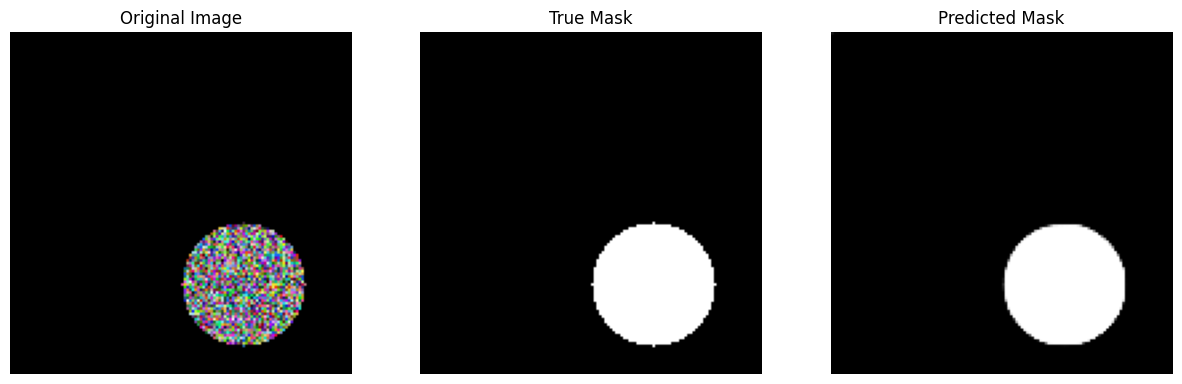

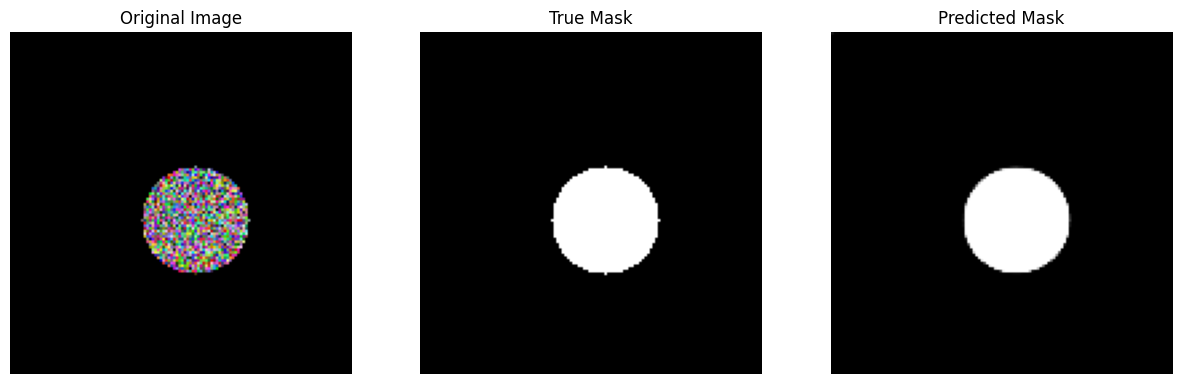

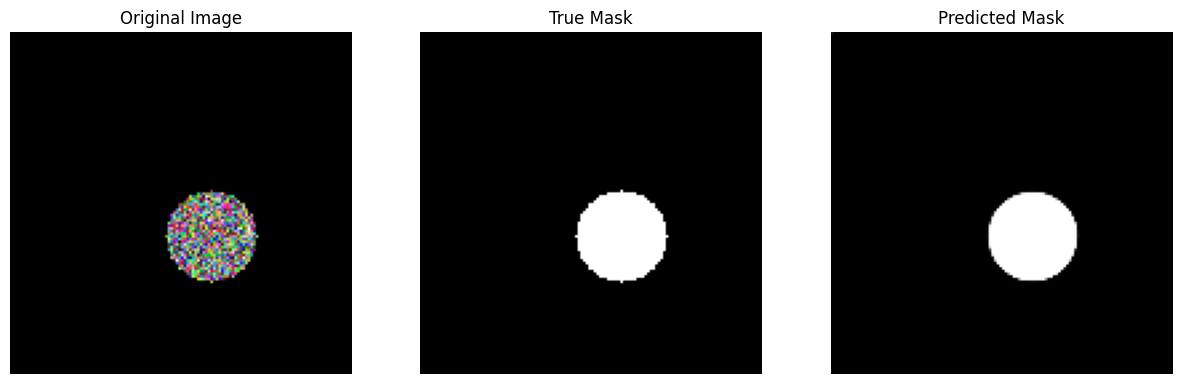

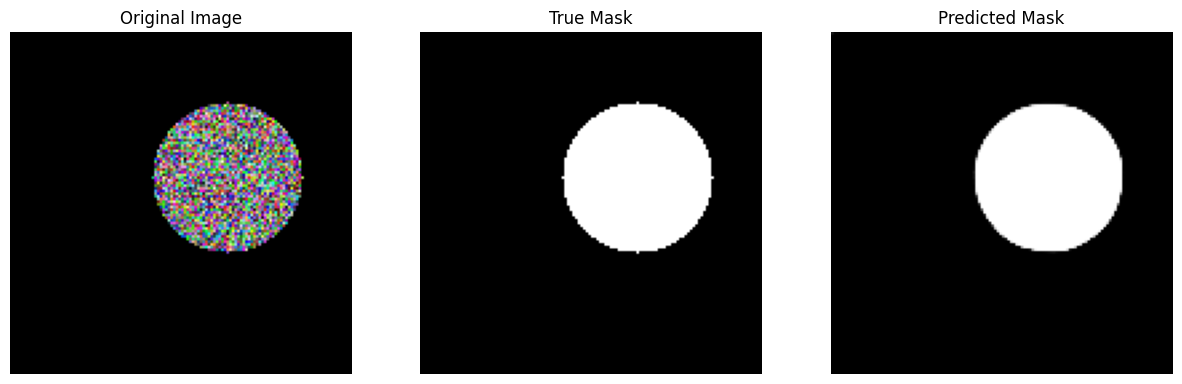

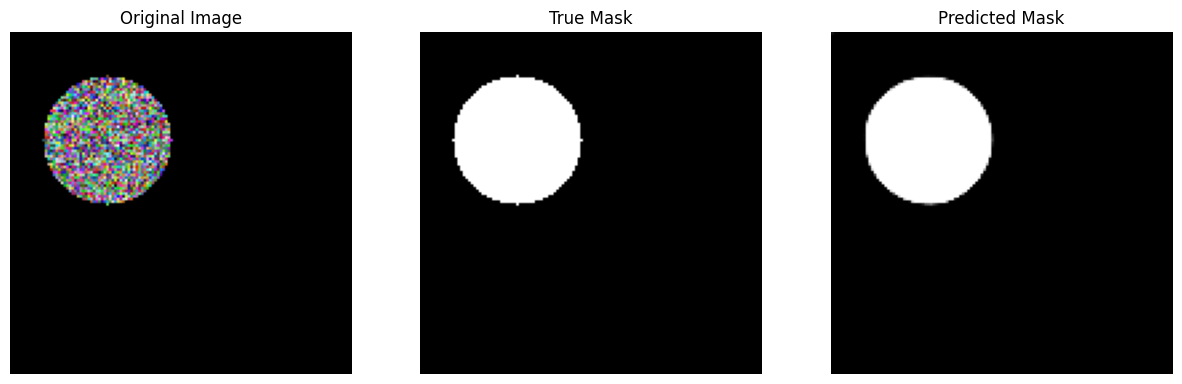

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2DTranspose, Activation
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Generate synthetic data
img_size = 128
num_samples = 1000
images = np.zeros((num_samples, img_size, img_size, 3), dtype=np.float32)
masks = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

for i in range(num_samples):
    cx, cy = np.random.randint(img_size//4, 3*img_size//4, 2)
    r = np.random.randint(img_size//8, img_size//4)
    y, x = np.ogrid[:img_size, :img_size]
    mask = (y - cy)**2 + (x - cx)**2 <= r**2
    masks[i, :, :, 0] = mask
    images[i, :, :, :] = np.random.rand(img_size, img_size, 3) * mask[..., np.newaxis]

# Define the segmentation model
input_shape = (img_size, img_size, 3)
inputs = tf.keras.Input(input_shape)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2D(1, (3, 3), padding='same')(x)
x = Activation('sigmoid')(x)

# Compile the model
model = Model(inputs=inputs, outputs=x)
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
model.fit(images, masks, batch_size=32, epochs=10, validation_split=0.1)

# Get predictions
predictions = model.predict(images[:5])

# Plot images, masks, and predictions
for i in range(5):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(images[i])
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(masks[i, :, :, 0], cmap='gray')
    plt.title('True Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i, :, :, 0], cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    plt.show()


### Generating Synthetic Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
img_size = 128
num_samples = 1000
images = np.zeros((num_samples, img_size, img_size, 3), dtype=np.float32)
masks = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

for i in range(num_samples):
    cx, cy = np.random.randint(img_size//4, 3*img_size//4, 2)
    r = np.random.randint(img_size//8, img_size//4)
    y, x = np.ogrid[:img_size, :img_size]
    mask = (y - cy)**2 + (x - cx)**2 <= r**2
    masks[i, :, :, 0] = mask
    images[i, :, :, :] = np.random.rand(img_size, img_size, 3) * mask[..., np.newaxis]

## Building Upon Baseline MobileNetV2

Epoch 1/10
29/29 [==============================] - 46s 168ms/step - loss: 0.4035 - val_loss: 0.2688
Epoch 2/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2677 - val_loss: 0.2628
Epoch 3/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2653 - val_loss: 0.2626
Epoch 4/10
29/29 [==============================] - 3s 88ms/step - loss: 0.2647 - val_loss: 0.2649
Epoch 5/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2637 - val_loss: 0.2624
Epoch 6/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2636 - val_loss: 0.2621
Epoch 7/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2628 - val_loss: 0.2616
Epoch 8/10
29/29 [==============================] - 3s 90ms/step - loss: 0.2631 - val_loss: 0.2612
Epoch 9/10
29/29 [==============================] - 3s 89ms/step - loss: 0.2623 - val_loss: 0.2644
Epoch 10/10
1/1 [==============================] - 1s 1s/step


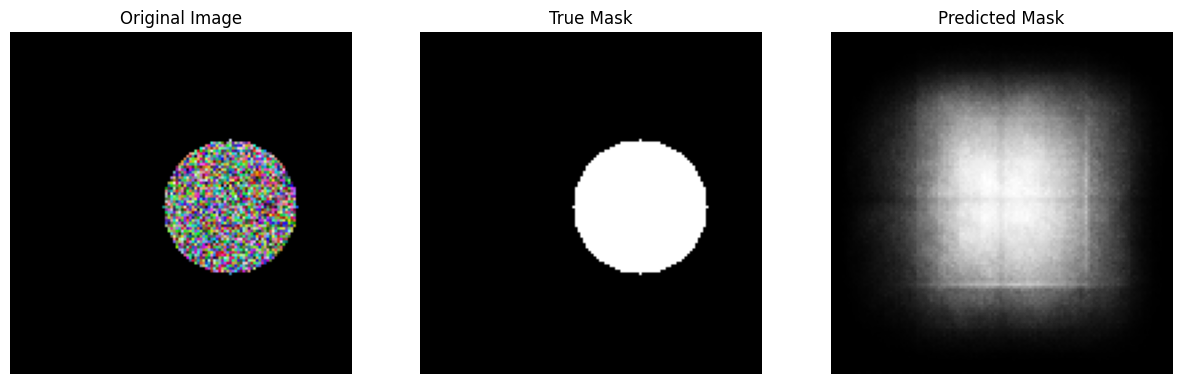

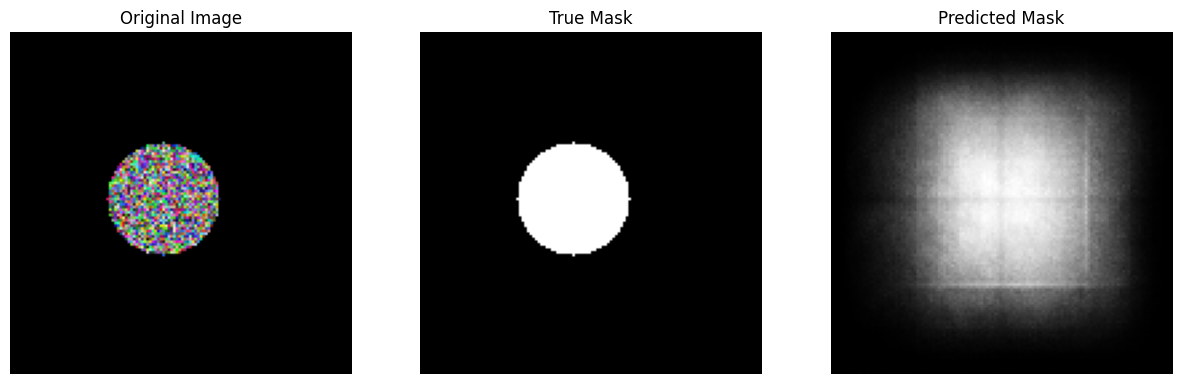

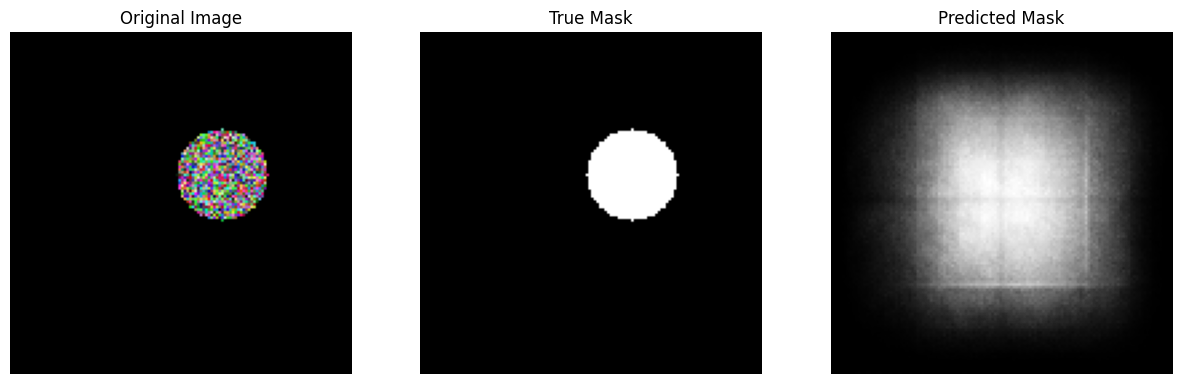

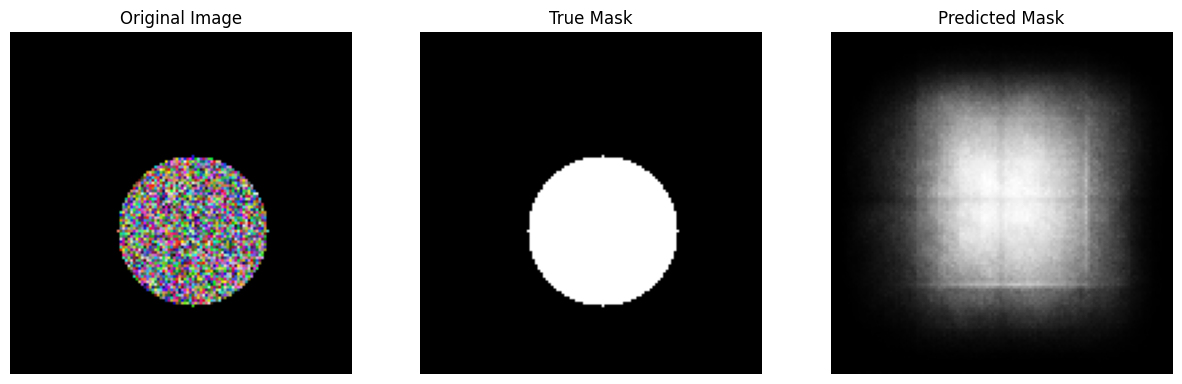

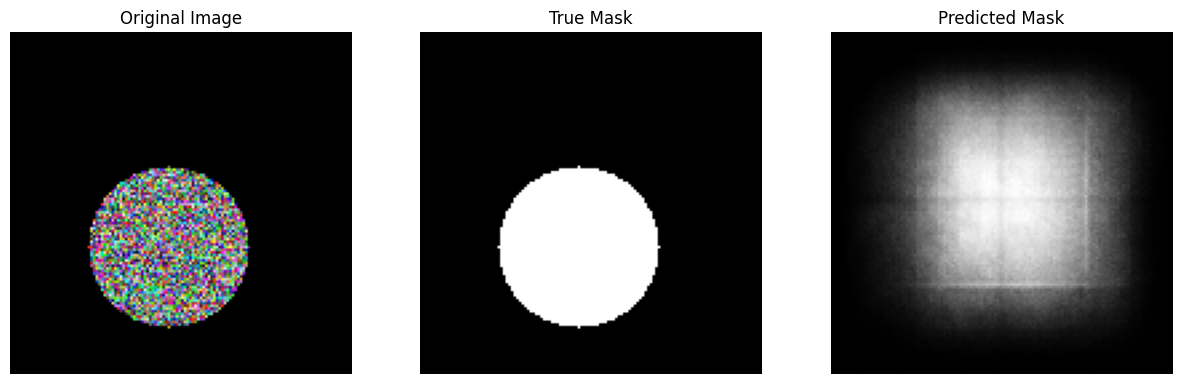

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Activation
from tensorflow.keras.models import Model

# Load pre-trained MobileNetV2 model + higher level layers
base_model = tf.keras.applications.MobileNetV2(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')

# Create segmentation model
inputs = tf.keras.Input(shape=(img_size, img_size, 3))
x = base_model(inputs, training=False)
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(16, (3, 3), strides=(2, 2), padding='same', activation='relu')(x) # Additional upsampling layer
x = Conv2D(1, (3, 3), padding='same')(x)
x = Activation('sigmoid')(x)

# Compile the model
model = Model(inputs=inputs, outputs=x)
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
model.fit(images, masks, batch_size=32, epochs=10, validation_split=0.1)

# Get predictions
predictions = model.predict(images[:5])

# Plot images, masks, and predictions
for i in range(5):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(images[i])
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(masks[i, :, :, 0], cmap='gray')
    plt.title('True Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i, :, :, 0], cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    plt.show()

## Image Segmentation for Oxford dataset

In [ ]:
!pip install git+https://github.com/tensorflow/examples.git

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-0qaqadfy
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-0qaqadfy
  Resolved https://github.com/tensorflow/examples.git to commit 0bbf4fe43fbf41b7174b9ce4a64d69bd33aadd21
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1689703202.67065300351684276117070052891639684042406419745-py3-none-any.whl size=301555 sha256=528bcd59007ab85e910ffbc8ee2511310b40a44965332aba21489f0358ab1571
  Stored in directory: /tmp/pip-ephem-wheel-cache-_ilblcjk/wheels/72/5f/d0/7fe769eaa229bf20101d11a357eb23c83c481bee2d7f710599
Successfully built tensorflow-examples


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output
import matplotlib.pyplot as plt

## Load the dataset

In [ ]:
dataset, info = tfds.load('oxford_iiit_pet:3.*.*', with_info=True)

def normalize(input_image, input_mask):
  input_image = tf.cast(input_image, tf.float32) / 255.0
  input_mask -= 1
  return input_image, input_mask

def load_image(datapoint):
  input_image = tf.image.resize(datapoint['image'], (128, 128))
  input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  input_image, input_mask = normalize(input_image, input_mask)
  return input_image, input_mask

###

In [ ]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

test_batches = test_images.batch(BATCH_SIZE)

In [ ]:
def display(display_list):
  plt.figure(figsize=(15, 15))
  title = ['Input Image', 'True Mask', 'Predicted Mask']
  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False

up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[128, 128, 3])
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])
  last = tf.keras.layers.Conv2DTranspose(filters=output_channels, kernel_size=3, strides=2, padding='same')
  x = last(x)
  return tf.keras.Model(inputs=inputs, outputs=x)


9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
OUTPUT_CLASSES = 3

model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

EPOCHS = 20
VAL_SUBSPLITS = 5
VALIDATION_STEPS = info.splits['test'].num_examples//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(train_batches, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_batches)


Epoch 1/20
57/57 [==============================] - 27s 155ms/step - loss: 0.5107 - accuracy: 0.8018 - val_loss: 0.4332 - val_accuracy: 0.8535
Epoch 2/20
57/57 [==============================] - 10s 142ms/step - loss: 0.3002 - accuracy: 0.8864 - val_loss: 0.3102 - val_accuracy: 0.8876
Epoch 3/20
57/57 [==============================] - 8s 140ms/step - loss: 0.2752 - accuracy: 0.8943 - val_loss: 0.2849 - val_accuracy: 0.8922
Epoch 4/20
57/57 [==============================] - 8s 141ms/step - loss: 0.2603 - accuracy: 0.8994 - val_loss: 0.2789 - val_accuracy: 0.8955
Epoch 5/20
57/57 [==============================] - 8s 148ms/step - loss: 0.2545 - accuracy: 0.9011 - val_loss: 0.2788 - val_accuracy: 0.8935
Epoch 6/20
57/57 [==============================] - 8s 144ms/step - loss: 0.2440 - accuracy: 0.9044 - val_loss: 0.2682 - val_accuracy: 0.8994
Epoch 7/20
57/57 [==============================] - 8s 145ms/step - loss: 0.2353 - accuracy: 0.9075 - val_loss: 0.2614 - val_accuracy: 0.9011
Epoc

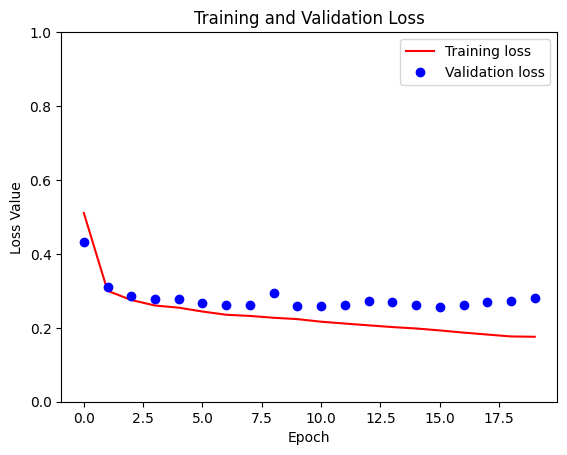

2/2 [==============================] - 1s 43ms/step


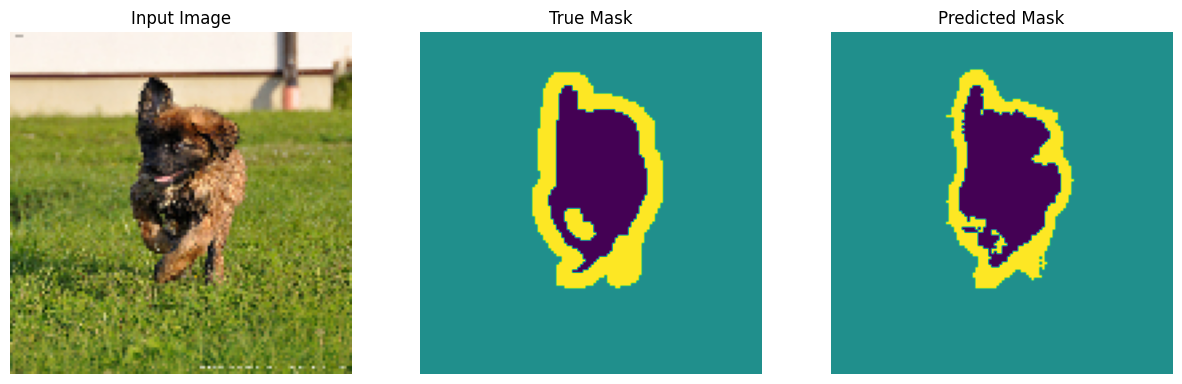

2/2 [==============================] - 0s 48ms/step


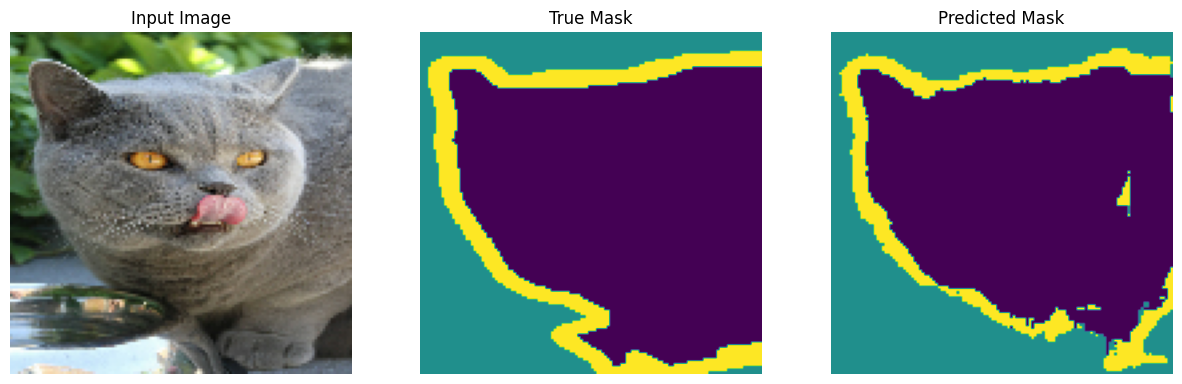

2/2 [==============================] - 0s 41ms/step


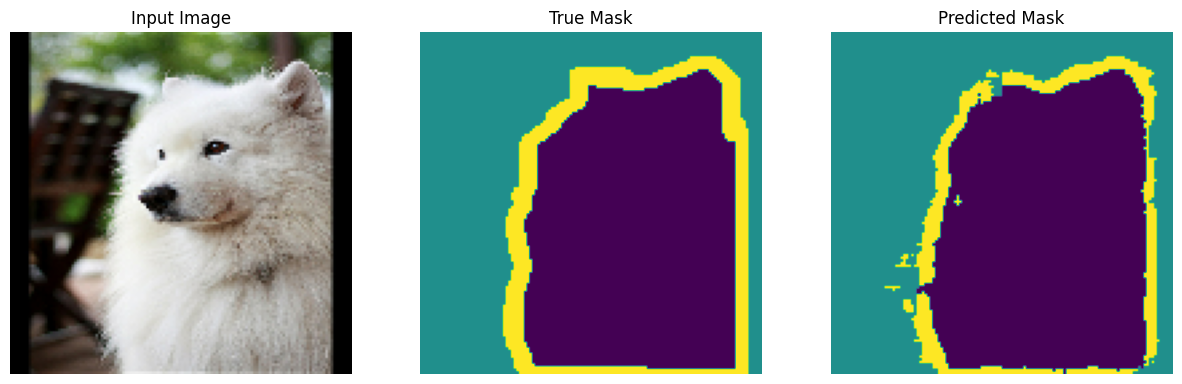

In [ ]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

show_predictions(test_batches, 3)